<a href="https://colab.research.google.com/github/Batmansanty49/ProcesamientoDigitalDeSe-alesTarea1/blob/main/TAREA_1_Discrete_Time_Signal_Operations_v5_audio_SantiagoRuizRam%C3%ADrez_EmilianoOrtizBrise%C3%B1o_SofiaAlejandraHernandezNativita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# TAREA 1 — Discrete Time Signal Operations

**Fecha:** 2026-02-16  
**Tema (clase de hoy):** Operaciones en señales en tiempo discreto (DT)

> Entrega: **un solo notebook** con tus soluciones y gráficas.



## Relación con **Serie 1 (ejercicios en papel)**

Esta tarea es la **extensión computacional** de la Serie 1.

**Flujo recomendado (por ejercicio):**
1) Resuelve **en papel** (análisis / fórmulas / razonamiento).
2) Implementa aquí para **verificar** con código y gráficas.
3) Si hay contradicción: **debug** hasta entender el error (en el papel o en el código).

### Mapeo rápido (Serie 1 → Notebook)

- **Serie 1 #4** (u[n], δ[n], r[n]) → **Notebook Ejercicio 1**
- **Serie 1 #2** (periodicidad de cos) → **Notebook Ejercicio 2**
- **Serie 1 #5–7** (inversión y corrimientos) → **Notebook Ejercicio 3**
- **Serie 1 #11** (media y RMS) → **Notebook Ejercicio 4**
- **Serie 1 #9** (energía de (0.9)^n u[n]) → **Notebook Ejercicio 5**
- **Serie 1 #12** (auto/cross correlación) → **Notebook Ejercicio 6**



## Reglas (importantes)

- Puedes usar ChatGPT (u otra IA) **solo como verificador**.
- Tu notebook debe incluir tu razonamiento (comentarios) y tu código.
- **No uses atajos** que oculten la idea:
  - `np.roll`, `np.flip`, `x[::-1]` (para inversión), `np.convolve`, `np.correlate`
- Sí puedes usar NumPy básico, `for` loops, y operaciones elementales.

**Pista:** Si tu solución cabe en 1 línea usando una función “mágica”, probablemente no cuenta.


**Clave:** La IA NO sustituye el papel. Úsala para *verificar* y para detectar errores, igual que usarías una calculadora.



## 1) Datos del estudiante

Completa esta celda y vuelve a correrla.


In [ ]:

# === Datos del estudiante ===
NOMBRE = "\n Sofia Alejandra Hernández Nativitas \n Emiliano Ortiz Briseño \n Santiago Ruiz Ramírez"
GRUPO = "3"

print("Nombre integrantes:", NOMBRE)
print("Grupo:", GRUPO)


Nombre integrantes: 
 Sofia Alejandra Hernández Nativitas 
 Emiliano Ortiz Briseño 
 Santiago Ruiz Ramírez
Grupo: 3



## 2) Imports y configuración (no modificar)

Esta sección es scaffolding para que no pierdas tiempo con formato de gráficas.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)



## 3) (Opcional) Subir foto de tu libreta / sketch

Si dibujas a mano alguna señal, puedes subirla aquí como evidencia.


In [21]:

# (Opcional) En Colab:
from google.colab import files
uploaded = files.upload()

# (Opcional) Mostrar una imagen subida (si aplica):
#from PIL import Image
#import io
#fname = list(uploaded.keys())[0]
#img = Image.open(io.BytesIO(uploaded[fname]))
#plt.figure(figsize=(6,4))
#plt.imshow(img); plt.axis("off"); plt.title(fname)
#plt.show()


Saving TAREA_1_Señales_SantiagoRuizRamírez_EmilianoOrtizBriseño_SofiaAlejandraHernandezNativita_Completa.pdf to TAREA_1_Señales_SantiagoRuizRamírez_EmilianoOrtizBriseño_SofiaAlejandraHernandezNativita_Completa.pdf



## 4) Funciones de graficación (scaffold)

Usa estas funciones para graficar de forma consistente.


In [ ]:

def stem_plot(n, x, title="", xlabel="n", ylabel="x[n]"):
    """Discrete-time stem plot."""
    n = np.asarray(n)
    x = np.asarray(x)
    markerline, stemlines, baseline = plt.stem(n, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

def compare_stem(n, x1, x2, label1="x1", label2="x2", title=""):
    """Compare two discrete-time signals on the same axes."""
    n = np.asarray(n)
    x1 = np.asarray(x1); x2 = np.asarray(x2)
    plt.stem(n, x1)
    plt.stem(n, x2)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel("amplitud")
    plt.legend([label1, label2])
    plt.grid(True)
    plt.show()



## 5) Funciones que debes implementar (TODO)

Implementa **sin** usar atajos (`np.roll`, `np.flip`, slicing invertido, etc.).


In [ ]:

def time_reverse(x):
    """Return x_rev[n] = x[-n] assuming x is indexed on n=0..N-1 (finite-length)."""
    start = 0
    end = len(x) - 1

    x_reverse = len(x) * [0.0]

    for i, val in enumerate(x):
        #Asignamos de atras hacia adelante
        x_reverse[-(i+1)] = val

    return x_reverse

def time_shift(x, k, pad_value=0.0):

    # Si k = 0, se queda igual
    if k == 0:
        return x

    # ATRASO (k < 0): agregamos padding al inicio segun el numero de k
    if k < 0:
        k_abs = abs(k)

        # Hacemos una lista con longitud de k elementos y lo llenamos con 0
        # Despues agregamos la lista que ya teniamos
        x_shift = [pad_value] * k_abs + list(x)

        return x_shift

    # ADELANTO (k > 0): agregamos padding al final
    else:

        # Hacemos una lista con longitud de k elementos y lo llenamos con 0
        x_padding_end = [pad_value] * k
        # Despues agregamos la lista que ya teniamos junto con el padding
        x_shift = list(x) + x_padding_end

        return x_shift

def energy(x):
    """E = sum |x[n]|^2 for the available samples."""

    #Variable para guardar la suma
    sum = 0

    #Suma total de la energia
    for i in range(0, len(x)):
      squad_value = x[i]**2
      sum = sum + squad_value

    return sum

def mean_value(x):
    """Mean over available samples."""
    #Numero de muestras a tomar
    N = len(x)

    #Por si la lista está vacía, evitamos división con cero
    if N == 0:
        return 0

    #Variable para la suma
    sum = 0

    #Sumamos todos los valores
    for i in range(0, N):
        sum = sum + x[i]

    #Dividimos la suma total entre el número de muestras
    mean = sum / N
    return mean

def rms(x):
    """RMS over available samples."""

    #Evitamos division entre 0
    if len(x) == 0:
        return 0

    #El RMS es la raíz cuadrada de la energía / número de muestras
    #Reutilizamos la función de energia y dividimos entre las muestras
    rms = energy(x) / len(x)

    #Elevamos a la 1/2
    rms = rms ** 0.5
    return rms


def autocorr(x):
    """Autocorrelation for lags k = -(N-1)..(N-1). Return (k_vals, rxx)."""
    return crosscorr(x, x)

def crosscorr(x, y):
    """Cross-correlation r_xy[k] for lags k = -(N-1)..(N-1). Return (k_vals, rxy)."""
    N = len(x)
    k_vals = np.arange(-(N-1), N)
    rxy = []

    for k in k_vals:
        suma_actual = 0.0
        for n in range(N):
            indice_y = n - k
            if 0 <= indice_y < len(y):
                suma_actual += x[n] * y[indice_y]

        rxy.append(suma_actual)

    return k_vals, np.array(rxy)



## 6) Ejercicios

En cada ejercicio:
1) escribe tu razonamiento en comentarios,
2) implementa,
3) grafica y verifica visualmente.



### Ejercicio 1 — Señales básicas

Para **-5 ≤ n ≤ 5**, construye y grafica:
- a) u[n]
- b) δ[n]
- c) r[n] = n u[n]

**TODO:** crea `n`, `u`, `delta`, `r` y grafícalas con `stem_plot`.


📌 Conecta con **Serie 1 #4** (u[n], δ[n], r[n]).

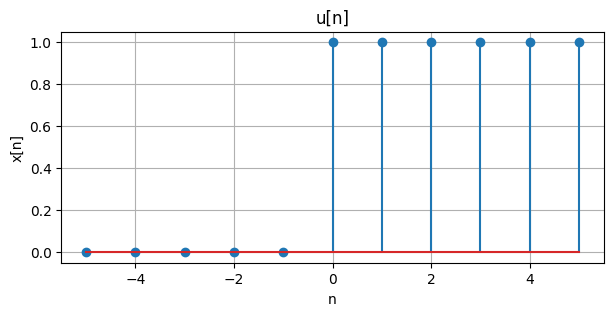

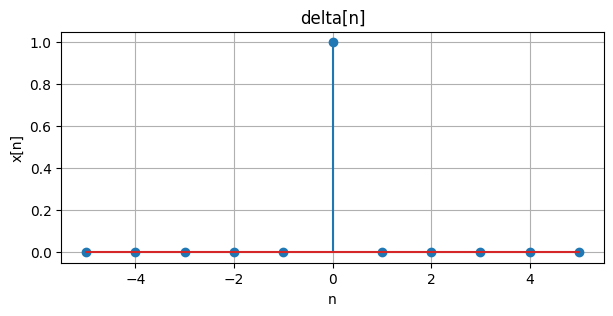

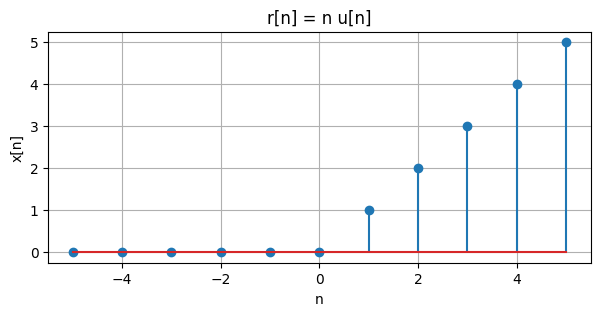

In [ ]:

# Rango de -5 a 5 que ocuparemos para graficar las tres funciones
n = np.arange(-5, 6)

# u[n]
#Arreglo vacio con 11 elementos
u = 11 * [0.0]

# Lista con los valores u[n]
for i in range (-5, 6):
  #Si n >= 0, u[n]=1
  if i > -1:
    u[i + 5] = 1
  #Si n < 0, u[n]=0
  else:
    u[i + 5] = 0

# δ[n]
#Arreglo vacio con 11 elementos
delta = 11 * [0.0]
# Buscamos el indice 0, que es el 5 en nuestra lista
# n[(-5 del rango minimo) + 5]; n[5] en lista
# Así cumplimos con la condicion, si n=0, entonces delta[n]=1
delta[5] = 1


# r[n] = n u[n]
# Rampa unitaria
# Arreglo vacio con 11 elementos
r = 11 * [0.0]
# Lista con los valores r[n]
for i in range (-5, 6):
  #Si n >= 0, u[n]=1
  if i > -1:
    r[i + 5] = i
  #Si n < 0, u[n]=0
  else:
    r[i + 5] = 0

# Graficar
stem_plot(n, u, title="u[n]")
stem_plot(n, delta, title="delta[n]")
stem_plot(n, r, title="r[n] = n u[n]")



### Ejercicio 2 — Periodicidad de x[n] = cos((5π/6)n)

1) Determina si es periódica.  
2) Si lo es, encuentra su **periodo fundamental** N0.

**TODO:** explica en texto (markdown o comentarios) y verifica con una gráfica de varios periodos.


📌 Conecta con **Serie 1 #2** (periodicidad de cos(·)).

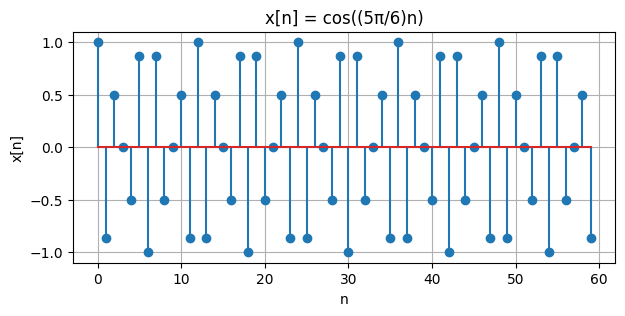

Arreglo de valores enteros, son multiplos del 12, por lo que 12 es nuestro periodo fundamental: 
 [0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132]


In [ ]:

# TODO: razonamiento aquí (comentarios)
"""
Si es periodica, la lógica que se sigio para encontrar la periodicidad fue:
Sabemos que la frecuencia angular 'W0' dividida entre 2pi da como resultado un número racional, qu etambién puede verse como una fracción de enteros 'k/N'.
Por lo tanto la formula queda:
W0/2pi = k/N
Despejando N:
N * W0 = k * 2pi
N = k * 2pi/W0
Con esto ya podemos obtener el periodo fundamental, en el formula:
W0= (5pi/6)
k tiene que ser el primer valor que haga que la operación sea entera, por ello probaremos con los números del 1 al 60.
Como se puede ver en la repsuestas del arreglo todos los valores positivos que salen son multiplos del 12, lo que significa que encontramos a nuestro perido fundamental.
"""
# Verificación numérica (opcional):
n = np.arange(0, 60)
x = np.cos((5*np.pi/6)*n)
stem_plot(n, x, title="x[n] = cos((5π/6)n)")
W0= (5*np.pi/6)
k= n
N0 = (2*np.pi*k)/W0
#print(N0)
valores_enteros = [int(np.round(x))for x in N0 if np.isclose(x, np.round(x))]
print("Arreglo de valores enteros, son multiplos del 12, por lo que 12 es nuestro periodo fundamental: \n",valores_enteros)




### Ejercicio 3 — Transformaciones en una secuencia finita

Dada: **x[n] = {1,2,3,4}** para n = 0,1,2,3

Calcula y grafica:
- a) x[-n]
- b) x[n-2]
- c) x[n+1]
- d) x[-n+2]
- e) x[3-n]

**Nota:** Define claramente tu eje n para cada resultado (con padding si hace falta).


📌 Conecta con **Serie 1 #5–7** (x[-n], x[n±k], composiciones).

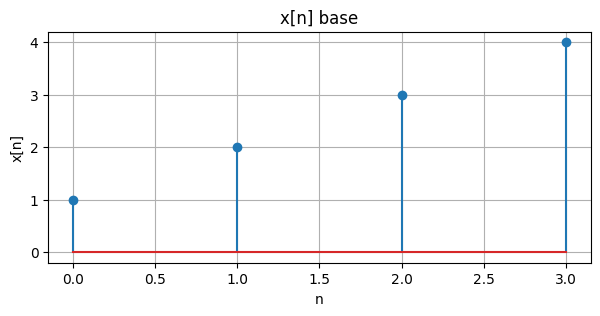

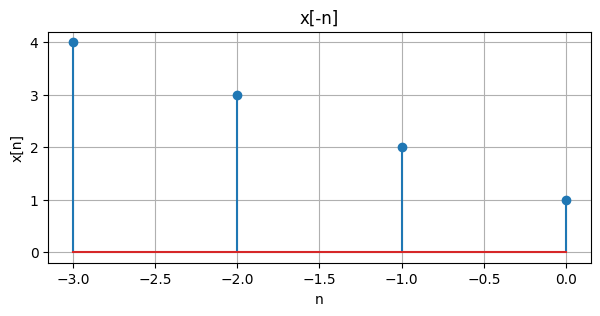

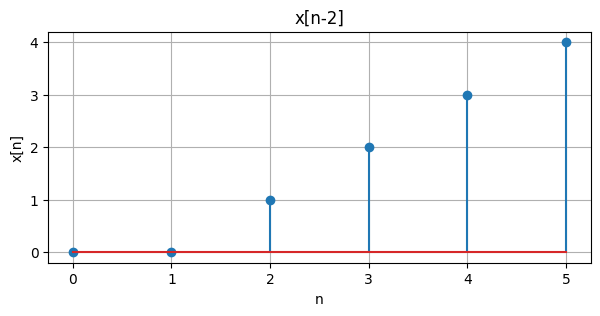

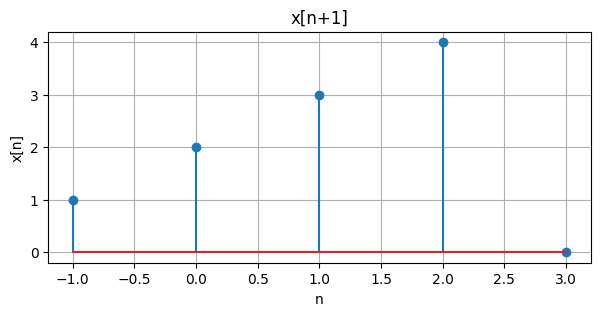

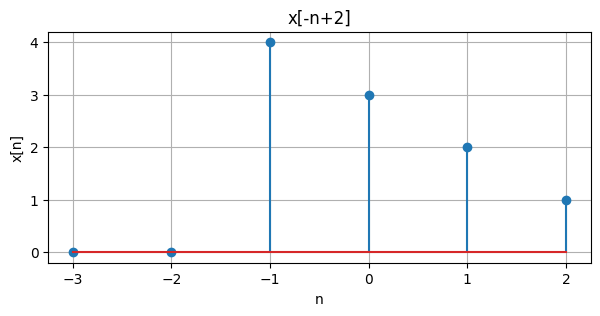

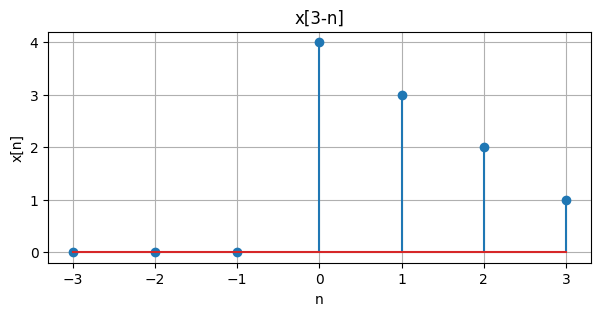

In [ ]:
# TODO: usa tus funciones time_reverse / time_shift
# x_rev = time_reverse(x)
# x_delay2 = time_shift(x, 2)
# x_adv1 = time_shift(x, -1)

# Luego construye:
# x_minus_n_plus_2 = ???  (composición)
# x_3_minus_n = ???       (composición)

# TODO: define ejes n adecuados y grafica cada resultado.

# Señal base x[n]
x = np.array([1,2,3,4], dtype=float)
# El rango va de [0, 3]
n = np.arange(0, len(x))
stem_plot(n, x, title="x[n] base")

# Señal x[-n]
x_rev = time_reverse(x)
# El rango va de [-3, 0]
n = np.arange(-len(x) + 1 , 1)
stem_plot(n, x_rev, title="x[-n]")

# Señal x[n-2]
x_delay2= time_shift(x, -2)
# El rango queda como [0, 5]
n2 = np.arange(0, len(x_delay2))
stem_plot(n2, x_delay2, title="x[n-2]")

# Señal x[n+1]
x_adv1= time_shift(x, 1)
# El rango es [-1, 3]
n3 = np.arange(-1, len(x_adv1) - 1)
stem_plot(n3, x_adv1, title="x[n+1]")

#Señal x[-n+2]
#Primero realizamos el desplazamiento de la señal
x_shift_3 = time_shift(x, 2)
#Luego invertimos la señal
x_minus_n_plus_2 = time_reverse(x_shift_3)
#Graficamos con un rango de [-3, 2]
n3 = np.arange(-3, len(x_minus_n_plus_2) -3)
stem_plot(n3, x_minus_n_plus_2, title="x[-n+2]")

#Señal x[3-n]
#Primero realizamos el desplazamiento de la señal
x_shift_4 = time_shift(x, 3)
#Luego invertimos la señal
x_minus_n_plus_3 = time_reverse(x_shift_4)
#Graficamos
n4 = np.arange(-3,len(x_minus_n_plus_3) -3)
stem_plot(n4, x_minus_n_plus_3, title="x[3-n]")



### Ejercicio 4 — Energía, media y RMS

Para x[n] = {2, -2, 2, -2} (n=0..3):

1) Calcula la **media**  
2) Calcula el **RMS**  
3) Interpreta: ¿media = 0 implica RMS = 0? (explica)

**TODO:** Implementa usando tus funciones `mean_value` y `rms`.

In [ ]:

x = np.array([2, -2, 2, -2], dtype=float)

m = mean_value(x)
print("Media:", m)

r = rms(x)
print("RMS:", r)

Media: 0.0
RMS: 2.0


La media = 0 no implica que el RMS sea cero. Si bien, la media es un promedio entre nuestros valores, en donde negativos y positivos se cancelan, el RMS se usa de forma distinta, sus valores se elevan al cuadrado en su formula, para así evitar que se anulen positivos y negativos, lo que nos dice el RMS es la tendencia que tiene de estar alejado del origen en x unidades. En este caso, nuestro promedio es cero, pero el RMS es de 2, ya que nuestros valores hacia arriba y hacia abajo se desplazan dos unidades.


### Ejercicio 5 — Energía (señal exponencial DT truncada)

Define una señal finita:
x[n] = (0.9)^n u[n]  para n = 0..30

1) Grafica x[n]  
2) Calcula la energía aproximada en ese intervalo (truncado)  
3) Explica qué pasaría si el intervalo fuera infinito (conceptual)

**TODO:** usa `energy(x)` y discute.


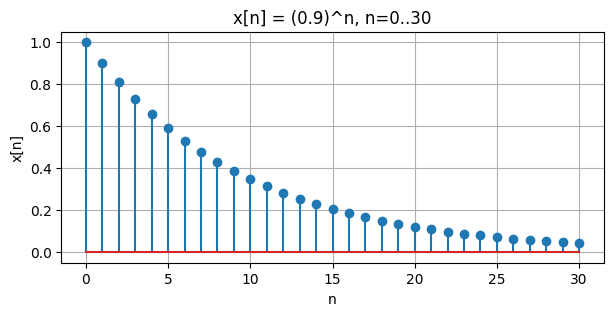

Energía (truncada 0..30): 5.255496956089839


In [ ]:
#Se genera un arreglo de 31 elementos con (0.9)^n
n = np.arange(0, 31)
x = (0.9**n)  # u[n]=1 para n>=0 en este rango

stem_plot(n, x, title="x[n] = (0.9)^n, n=0..30")

# TODO
E = energy(x)
print("Energía (truncada 0..30):", E)


Si el intervalo fuera infinito entonces veriamos como decrece asintoticamente nuestra grafica, ya que (0.9)^n tiende a cero a medida que aumeta el valor de n. Sin embargo, aunque no este delimitada, el valor es tan pequeño que al sacar el valor de energía, convergeriamos a un numero finito, similar al 5.2 que obtuvimos anteriormente, por lo que la señal seguiria siendo de energía.


### Ejercicio 6 — Correlación (sin funciones mágicas)

x[n] = {1,2,1}  
y[n] = {1,0,-1}

1) Calcula la **autocorrelación** r_xx[k]  
2) Calcula la **correlación cruzada** r_xy[k]  
3) Grafica r_xx[k] y r_xy[k] con eje de lags k.

**TODO:** implementa `autocorr` y `crosscorr` usando loops e índices.


📌 Conecta con **Serie 1 #12** (autocorrelación y correlación cruzada).

Lags (k): [-2 -1  0  1  2]
r_xx[k]: [1. 4. 6. 4. 1.]


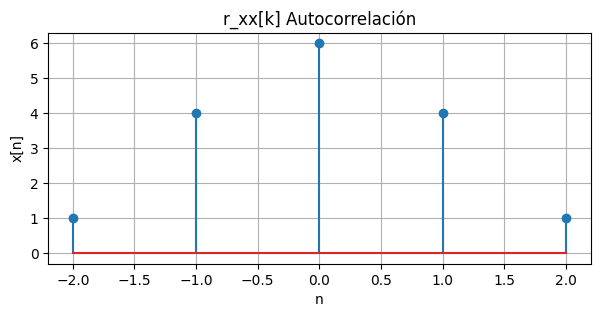

Lags (k): [-2 -1  0  1  2]
r_xy[k]: [-1. -2.  0.  2.  1.]


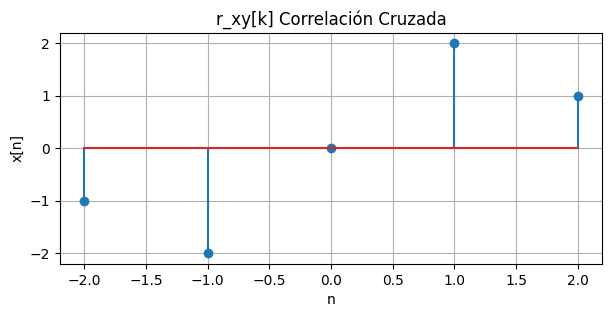

In [ ]:

x = np.array([1, 2, 1], dtype=float)
y = np.array([1, 0, -1], dtype=float)

# Autocorrelación
k, rxx = autocorr(x)
print("Lags (k):", k)
print("r_xx[k]:", rxx)
stem_plot(k, rxx, title="r_xx[k] Autocorrelación")

# Correlación cruzada
k, rxy = crosscorr(x, y)
print("Lags (k):", k)
print("r_xy[k]:", rxy)
stem_plot(k, rxy, title="r_xy[k] Correlación Cruzada")


Para poder realizar el ejercicio lo que hicimos fue que se dejo una señal fija mientras que la otra se iba desplazando en este caso dejamos fija la x[n] y fuimos recorriendo y[n] para el caso de la correlación cruzada y en la de autocorrelación usamos una x[n] y la otra x[n] la desplazamos  a travez de esta, revisando en que parte se sobreponian para de ahí multiplicar y sumar los resultados, así sacando cada uno de los resultados, esto en el código de las funciones se realizo mediante dos ciclos for anidados, uno para dezplazar la cantidad de pasos de dar, y el otro que recorre la senal movible para así ver en que espacios quedaron superpuestos con un if, realizando la suma unicamente en ese caso así solo regresando los valores para graficarlos.


## 🔊 Sección Audio (extensión opcional)

**Idea:** Graba audio (con tu celular, Audacity, etc.), guarda un `.wav` y súbelo al notebook.

- En **Colab**: usa `files.upload()` (celda siguiente).
- En **Jupyter local**: coloca el `.wav` en la misma carpeta del notebook y pon el nombre en `wav_path`.

> Esta sección es para experimentar con **señales reales** usando las mismas operaciones DT.


In [ ]:
# === (Colab) Subir WAV (MISMO PATRÓN DEL EJEMPLO) ===
from google.colab import files
uploaded = files.upload()  # elige tu archivo .wav

# TODO: escribe EXACTAMENTE el nombre del archivo que subiste (tal como aparece arriba)
wav_path = "PruebaTarea2.wav"

print("Usando wav_path =", wav_path)

Saving PruebaTarea2.wav to PruebaTarea2.wav
Usando wav_path = PruebaTarea2.wav


In [ ]:

# === Cargar WAV (se mantiene simple y robusto) ===
# Intentamos soundfile primero; si no está, usamos scipy.io.wavfile.
fs = None
audio = None

audio_loaded = False

try:
    import soundfile as sf
    audio, fs = sf.read(wav_path, dtype="float32", always_2d=False)
    audio_loaded = True
except Exception as e:
    print("soundfile falló o no está instalado:", e)

if not audio_loaded:
    try:
        from scipy.io import wavfile
        fs, audio_int = wavfile.read(wav_path)

        # Si es estéreo, toma un canal (puedes cambiarlo)
        if hasattr(audio_int, "ndim") and audio_int.ndim > 1:
            audio_int = audio_int[:, 0]

        # Normaliza a float32 en [-1, 1] si viene en entero
        if np.issubdtype(audio_int.dtype, np.integer):
            max_val = np.iinfo(audio_int.dtype).max
            audio = audio_int.astype("float32") / max_val
        else:
            audio = audio_int.astype("float32")

        audio_loaded = True
    except Exception as e:
        print("No pude cargar el WAV con scipy tampoco:", e)

if audio_loaded:
    print("fs =", fs, "Hz")
    print("muestras =", len(audio))


fs = 48000 Hz
muestras = 1496064


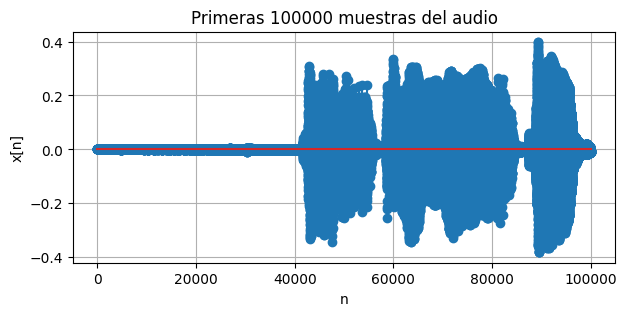

In [ ]:

# === Visualización (muestra corta) ===
# Graficamos solo las primeras N muestras para que se vea tipo DT.
N = 100000  # puedes cambiar
if audio is not None:
    n = np.arange(len(audio))
    stem_plot(n[:N], audio[:N, 0], title=f"Primeras {N} muestras del audio")

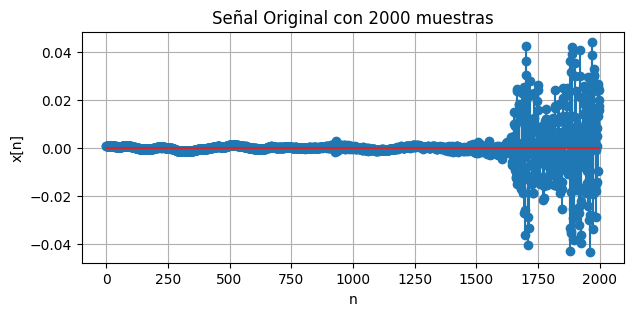

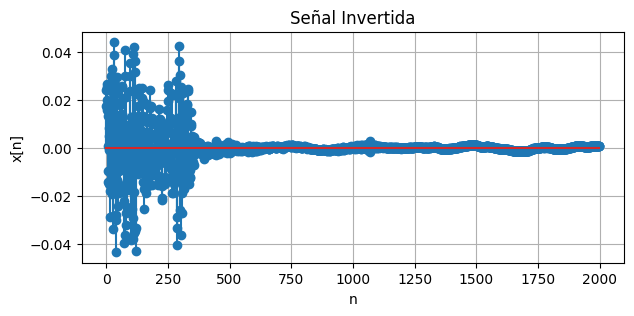

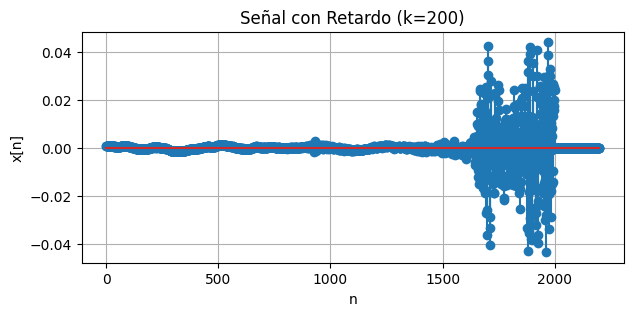

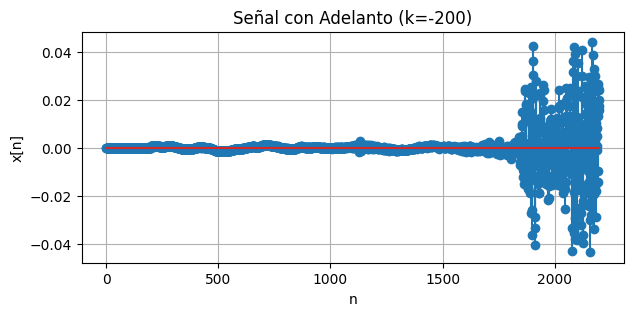

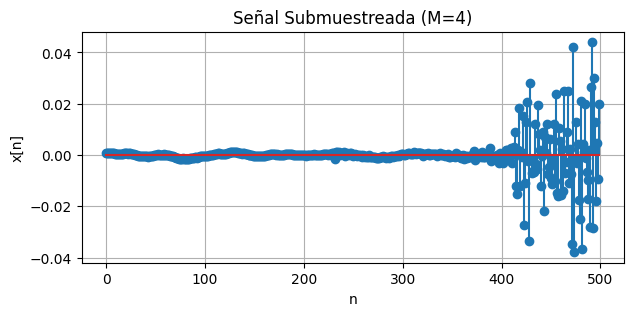

Energía:
Energía señal original:      0.0994
Energía señal invertida:     0.0994
Energía señal con retardo:   0.0994
Energía señal con adelanto:  0.0994
Energía señal submuestreada: 0.0245


'\n\nSe puede ver en la respuesta al pasar la señal original por la función energía que las señales \n\ninvertida, con retardo y adelanto no cambian de valor, para el caso de la señal invertida esto \nse debe a que se esta teniendo la misma cantidad de datos con los mismos valores, solo cambia \nsu orden, en el caso de los desplazamientos solo se estan recorriendo ceros ya sea a la izquierda\no derecha por lo que no afectan en el resultado final.\n\nEn el caso de la señal submuestrada si se ve un cambio de energia ya que solo estamos tomando 1 de\ncada 4 muestras de la señal original, lo que altera la suma final al haber menos valores para elevar \nal cuadrado y sumar, la energía total de la señal disminuye.\n'

In [20]:

# === Experimentos sugeridos (TODO) ===
# 1) Invertir: usa time_reverse(audio_short) sobre una ventana corta (ej. primeras 2000 muestras)
# 2) Corrimiento: aplica time_shift(..., k=200) (retardo) o k=-200 (adelanto)
# 3) Energía: compara energy(x) antes/después (¿cambia? ¿por qué?)
# 4) Submuestreo manual: crea x_ds = audio[::M] (aquí SÍ se permite slicing por submuestreo)
#
# Nota: Para no hacer señales enormes, trabaja con una ventana:
# audio_w = audio[:4000]
#
# TODO: implementa aquí tus pruebas y gráficas

#Elegimos de 40,000 a 42,000, porque como vi en el anterior el sonido empieza bien apartir de este valor
audioSeccionado = audio[40000:42000, 0]
senal_original = np.arange(len(audioSeccionado))
stem_plot(senal_original, audioSeccionado, title="Señal Original con 2000 muestras")

# Invertir
audio_rev = time_reverse(audioSeccionado)
senal_invertida = np.arange(len(audio_rev))
stem_plot(senal_invertida, audio_rev, title="Señal Invertida")

# Corrimiento
# Retardo de 200 muestras, aqui como vimos en los ejercicios anteriores al retardarla se restan 200
delay = time_shift(audioSeccionado, k=200)
senal_retardo = np.arange(len(delay))
stem_plot(senal_retardo, delay, title="Señal con Retardo (k=200)")

# Adelanto de 200 muestras, aqui como vimos en los ejercicios anteriores al adelantarla se suman 200
delay2 = time_shift(audioSeccionado, k=-200)
senal_adelanto = np.arange(len(delay2))
stem_plot(senal_adelanto, delay2, title="Señal con Adelanto (k=-200)")

# Submuestreo
# M es cuantas muestras tomamos en este caso tomamos 1 de cada 4 muestras
M = 4
senal_submuestreo = audioSeccionado[::M]
n_ds = np.arange(len(senal_submuestreo))
stem_plot(n_ds, senal_submuestreo, title=f"Señal Submuestreada (M={M})")

#Energia
energia_orig = energy(audioSeccionado)
energia_rev = energy(audio_rev)
energia_ret = energy(delay)
energia_ade = energy(delay2)
energia_sub = energy(senal_submuestreo)

print("Energía:")
print(f"Energía señal original:      {energia_orig:.4f}")
print(f"Energía señal invertida:     {energia_rev:.4f}")
print(f"Energía señal con retardo:   {energia_ret:.4f}")
print(f"Energía señal con adelanto:  {energia_ade:.4f}")
print(f"Energía señal submuestreada: {energia_sub:.4f}")

##Se puede ver en la respuesta al pasar la señal original por la función energía que las señales
##invertida, con retardo y adelanto no cambian de valor, para el caso de la señal invertida esto
##se debe a que se esta teniendo la misma cantidad de datos con los mismos valores, solo cambia
##su orden, en el caso de los desplazamientos solo se estan recorriendo ceros ya sea a la izquierda
##o derecha por lo que no afectan en el resultado final.

##En el caso de la señal submuestrada si se ve un cambio de energia ya que solo estamos tomando 1 de
##cada 4 muestras de la señal original, lo que altera la suma final al haber menos valores para elevar
##al cuadrado y sumar, la energía total de la señal disminuye.




## 7) IA (requerido)

Para **al menos 3 ejercicios**, incluye:

1) Tu solución manual/código  
2) El prompt exacto que usaste con IA  
3) Una comparación breve: ¿en qué coincide y en qué no? ¿por qué?

> Objetivo: aprender a **verificar**, no a copiar.


Para el ejercicio 2 tenemos que:

Is the signal x[n] = cos((5π/6)n) periodic? If yes, find its fundamental period.

La solución que realizamos a mano fue:

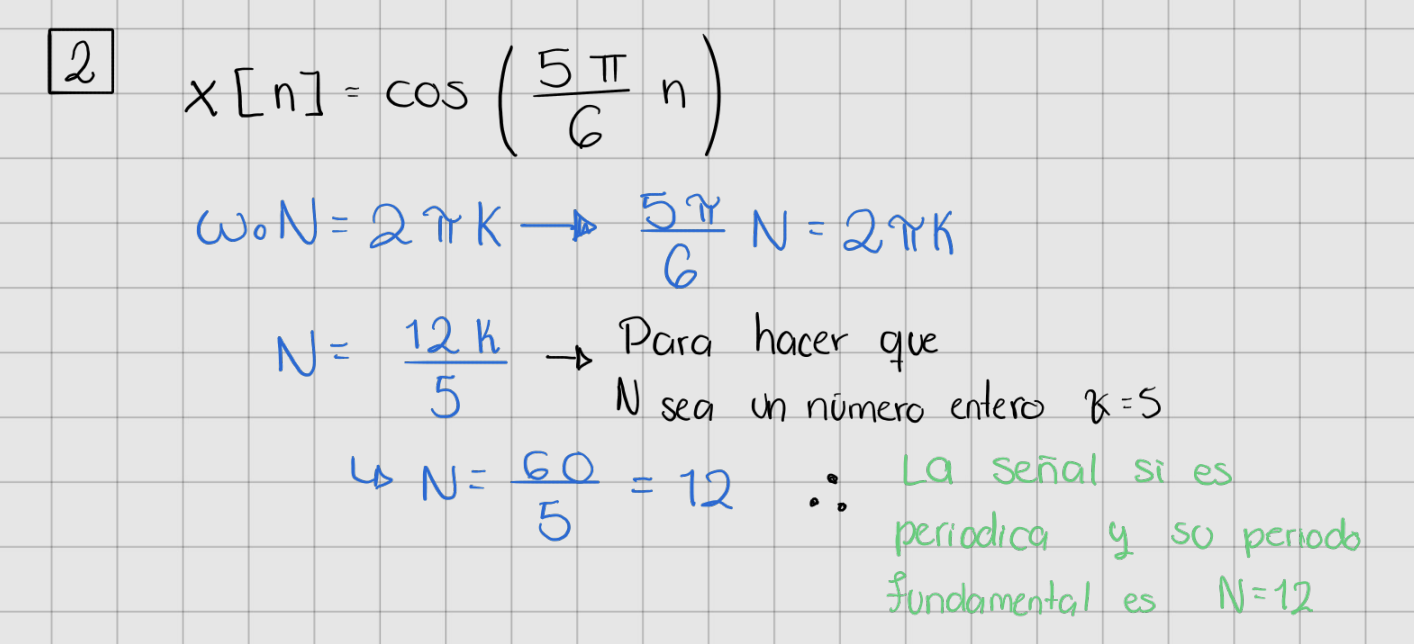

Para esta comparativa usamos la IA de Claude el modelo de Haiku 4.5, el promt usado fue:

'Ayudame a resolver ese ejercicio de procesamiento de señales, en el cual tenemos la señal  x[n] = cos((5π/6)n), puedes decirme si esta es periodica y si lo es puedes calcular su periodo funamental'

La respuesta que nos dio fue el mismo resultado que obtuvimos a mano:
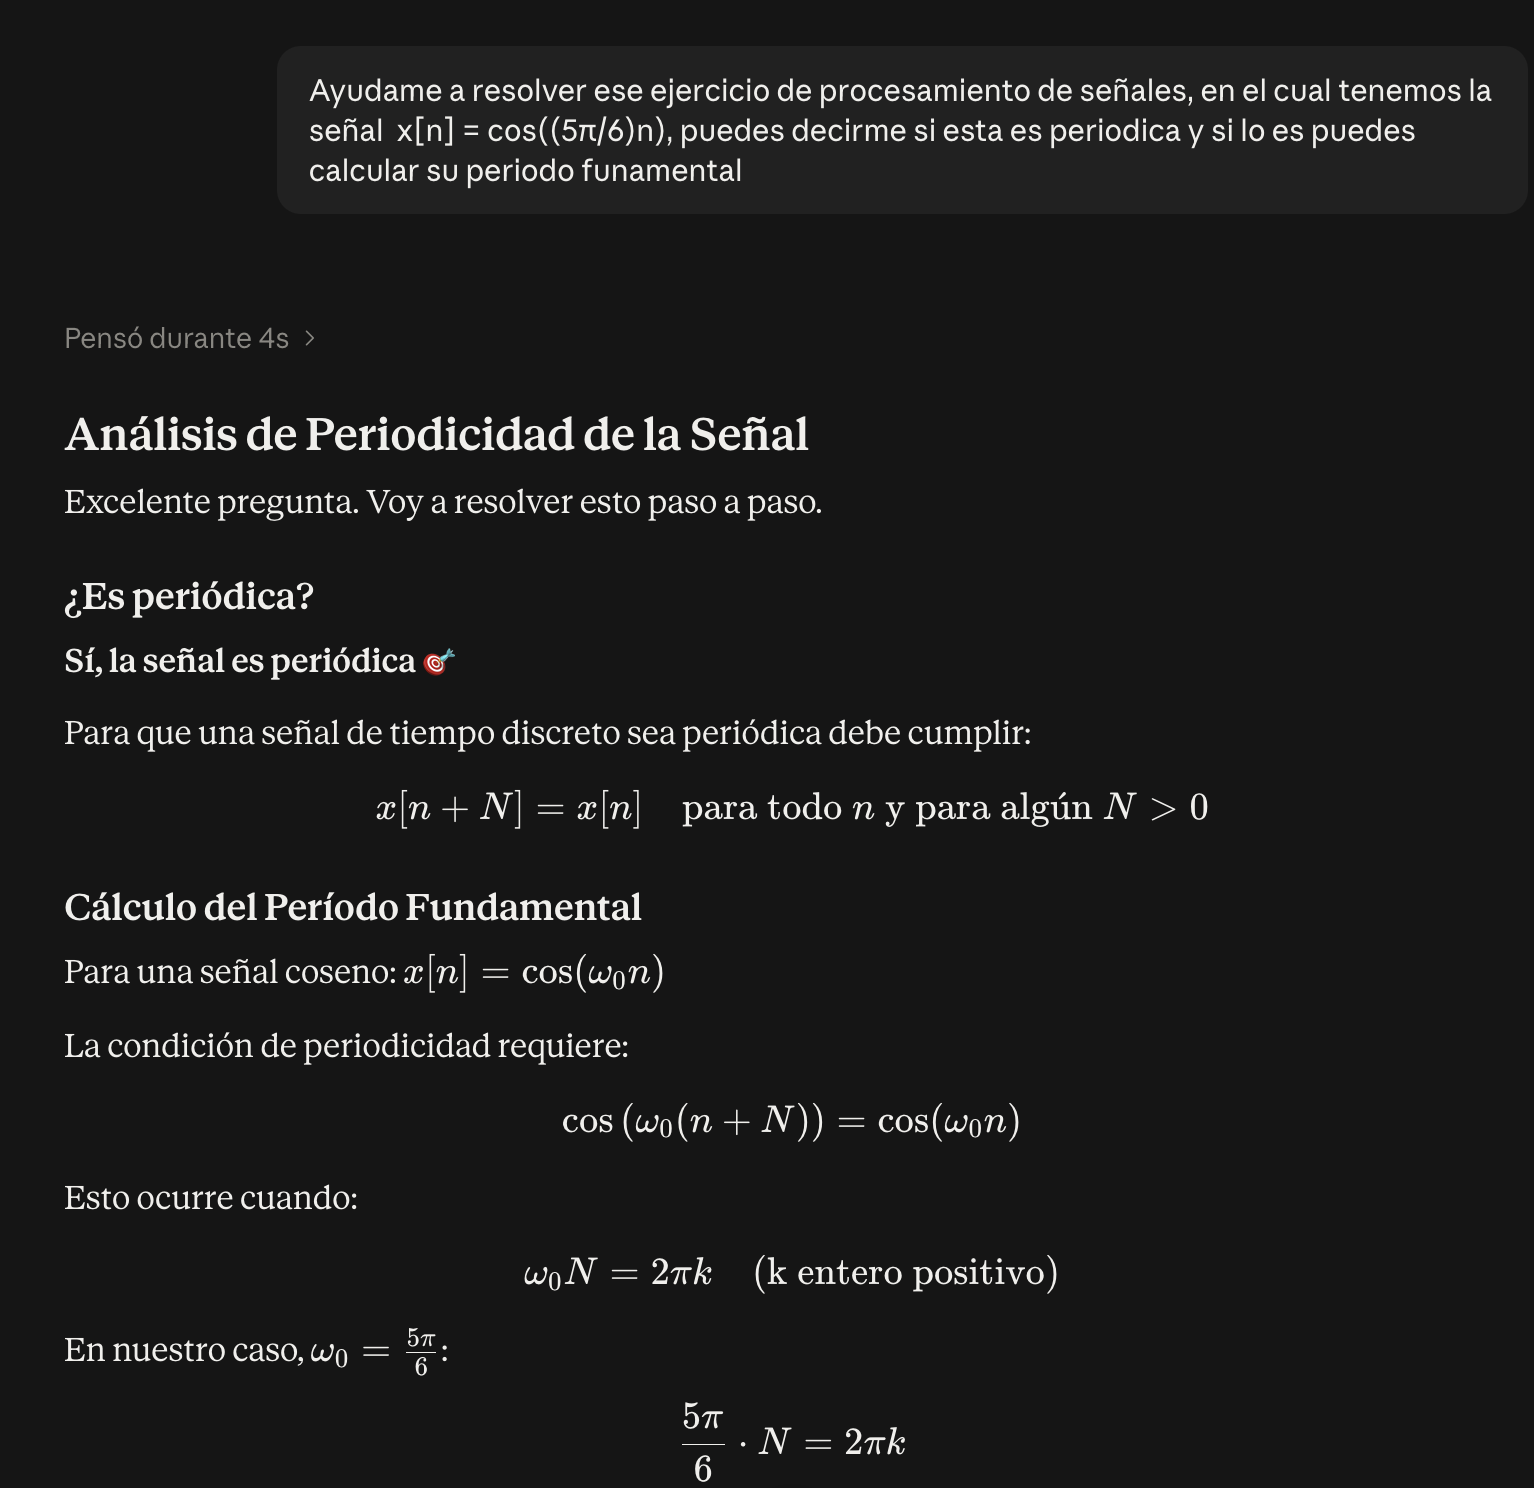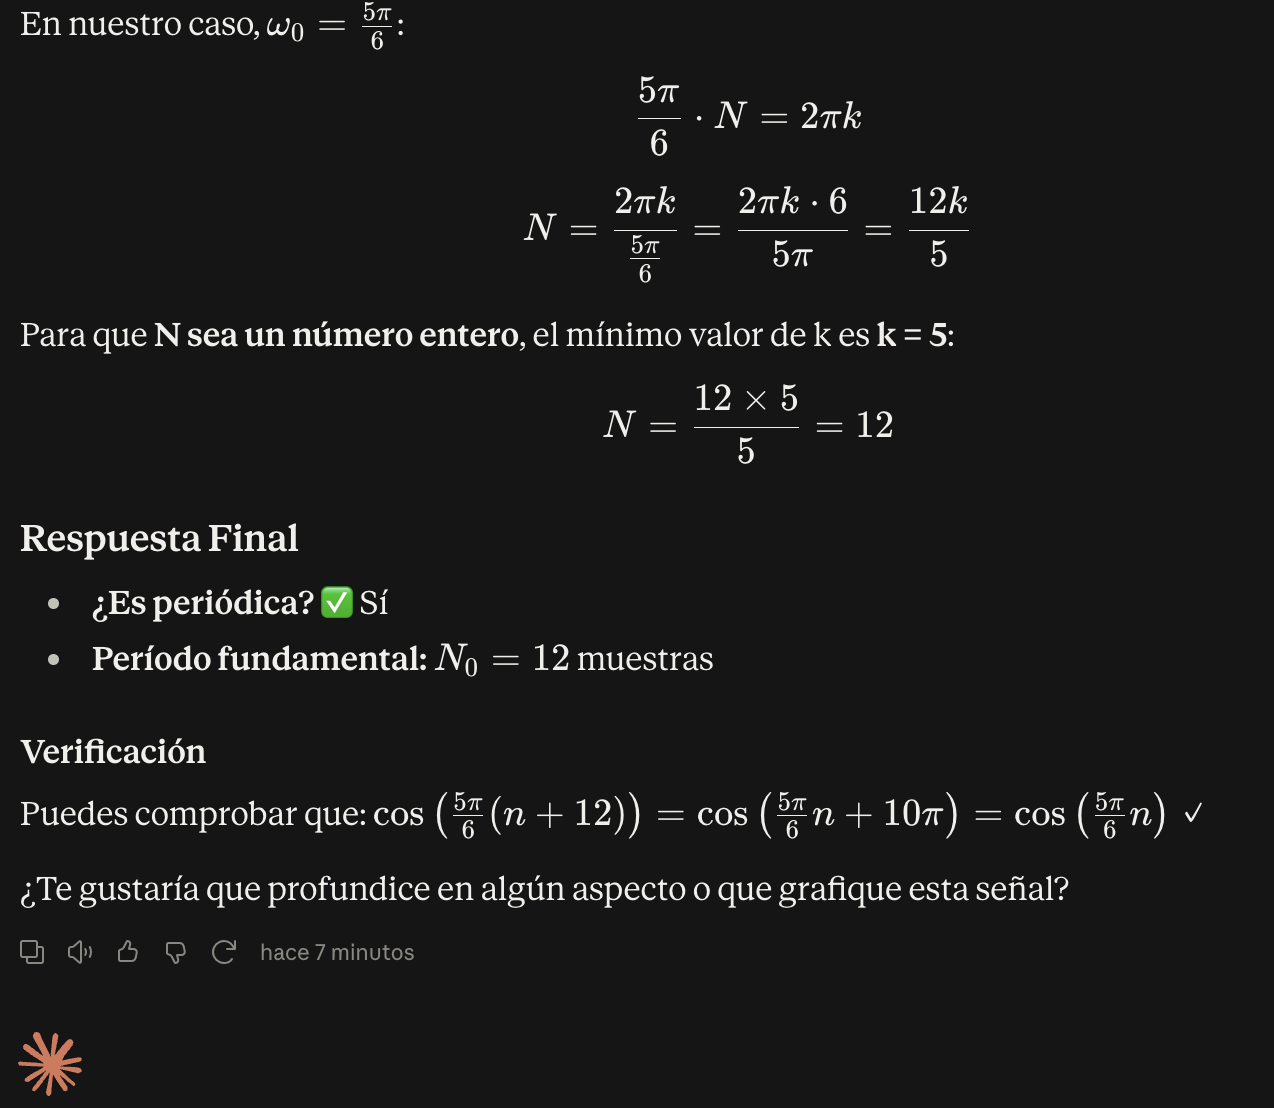

Podemos ver que las respuestas son identcias, inclusive la respuesta de Claude va un poco más alla y comprueba el resultado, sin embargo ambos estan desarrollados de manera correcta por lo que nuestro calculo fue correcto.


Para la pregunta 4 se solicita que:


Sketch the following signals for -5 ≤ n ≤ 5:


   a) u[n]


   b) δ[n]


   c) r[n] = n u[n]

Para ello nosotros lo que realizamos a mano fue:

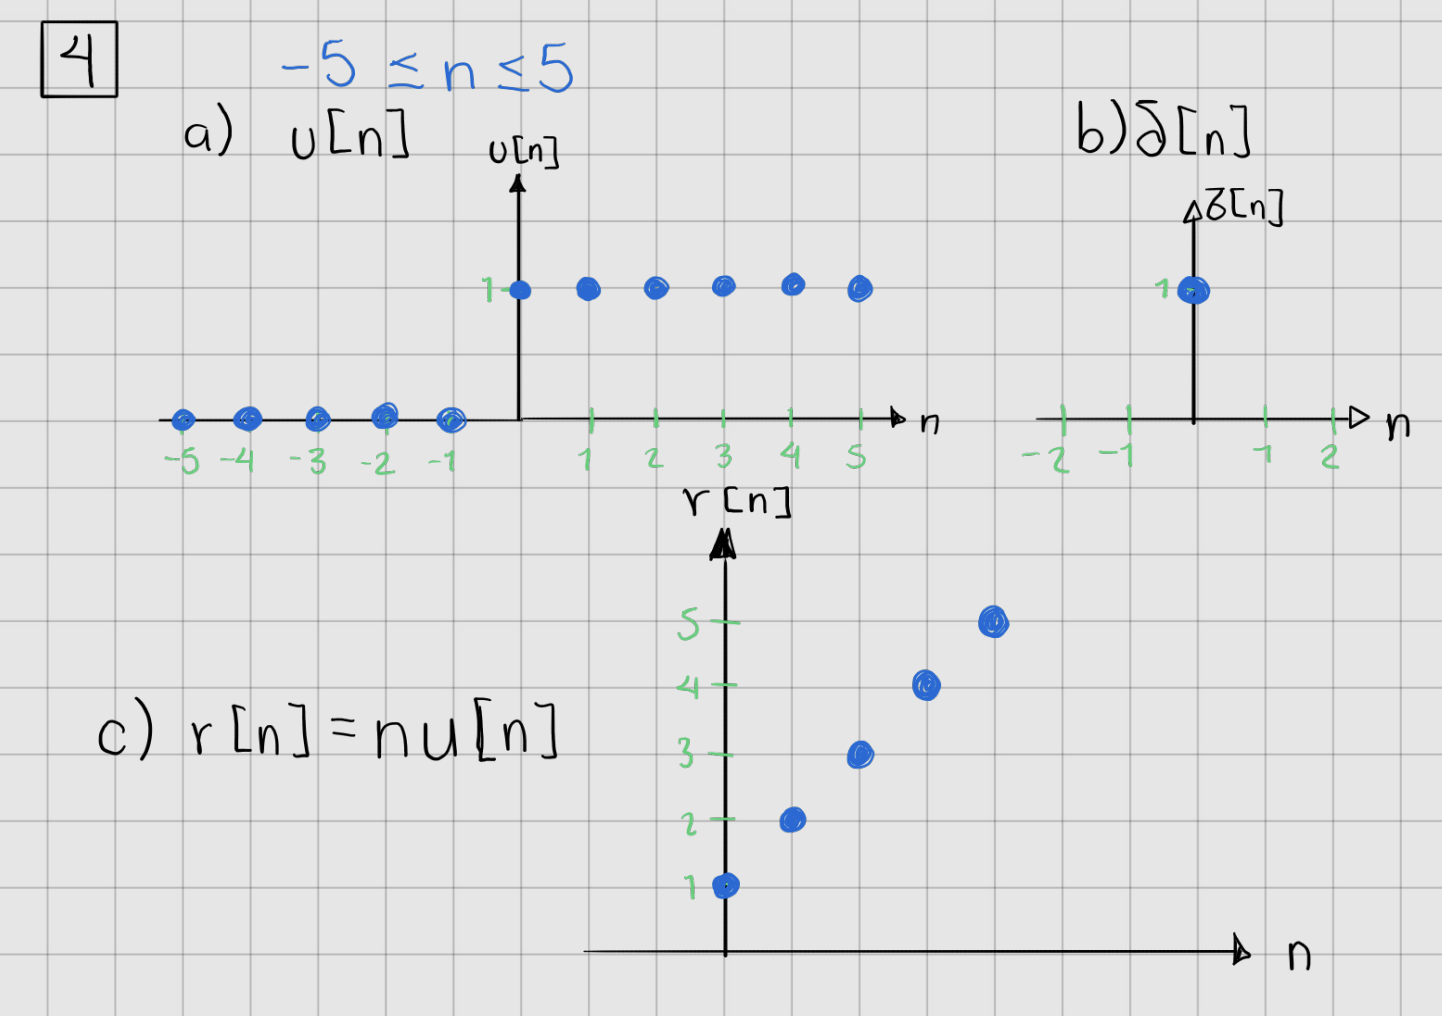

Para esta comparativa usamos la IA de Claude el modelo de Haiku 4.5, el promt usado fue:

'Ayudame a realizar las graficas de las siguientes señales para -5 ≤ n ≤ 5:
   
   a) u[n]
   
   b) δ[n]
      
   c) r[n] = n u[n]'

La respuesta que nos dio fue el mismo resultado que obtuvimos a mano:

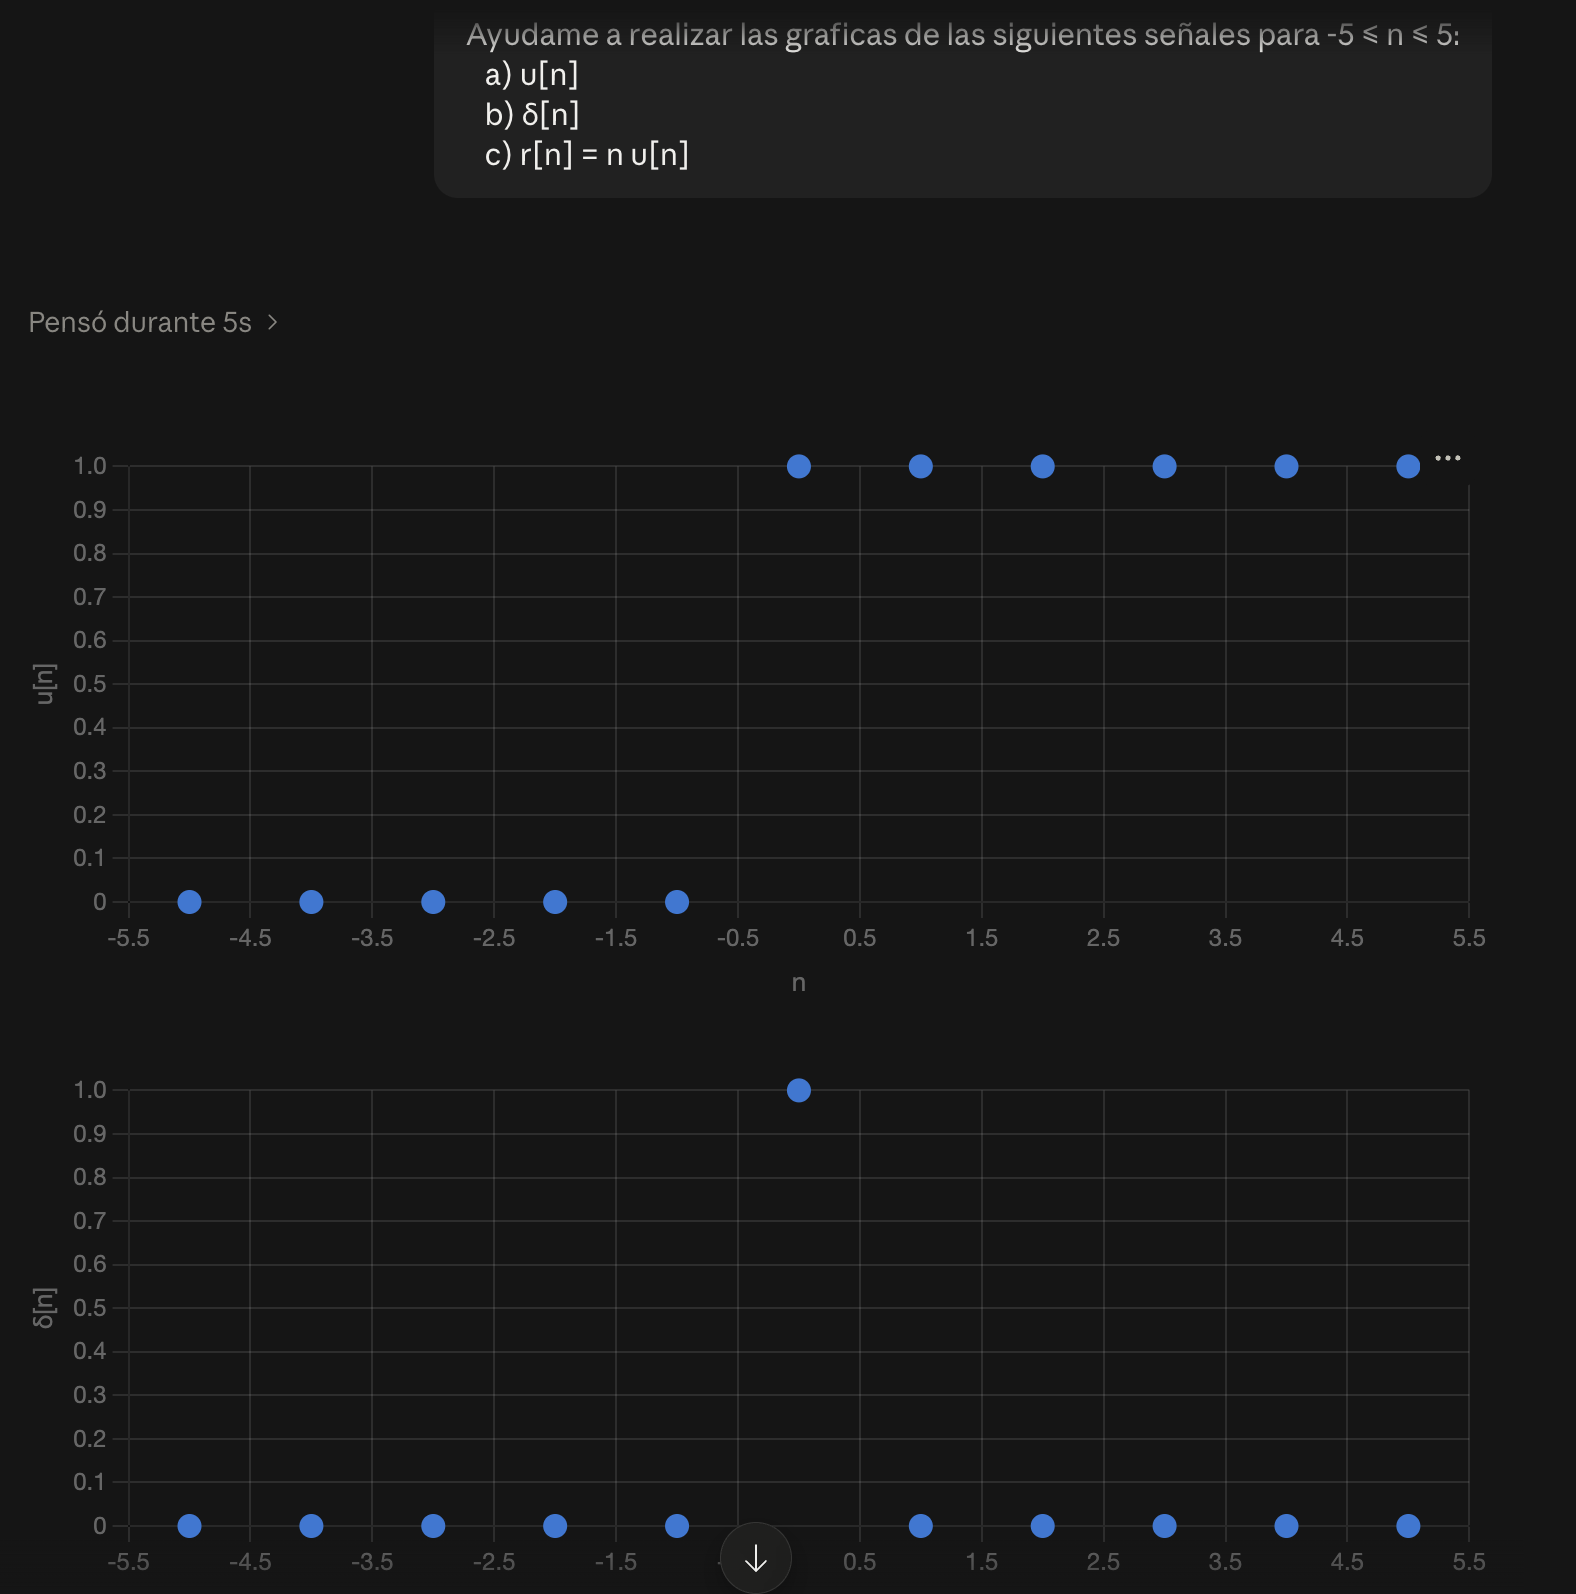

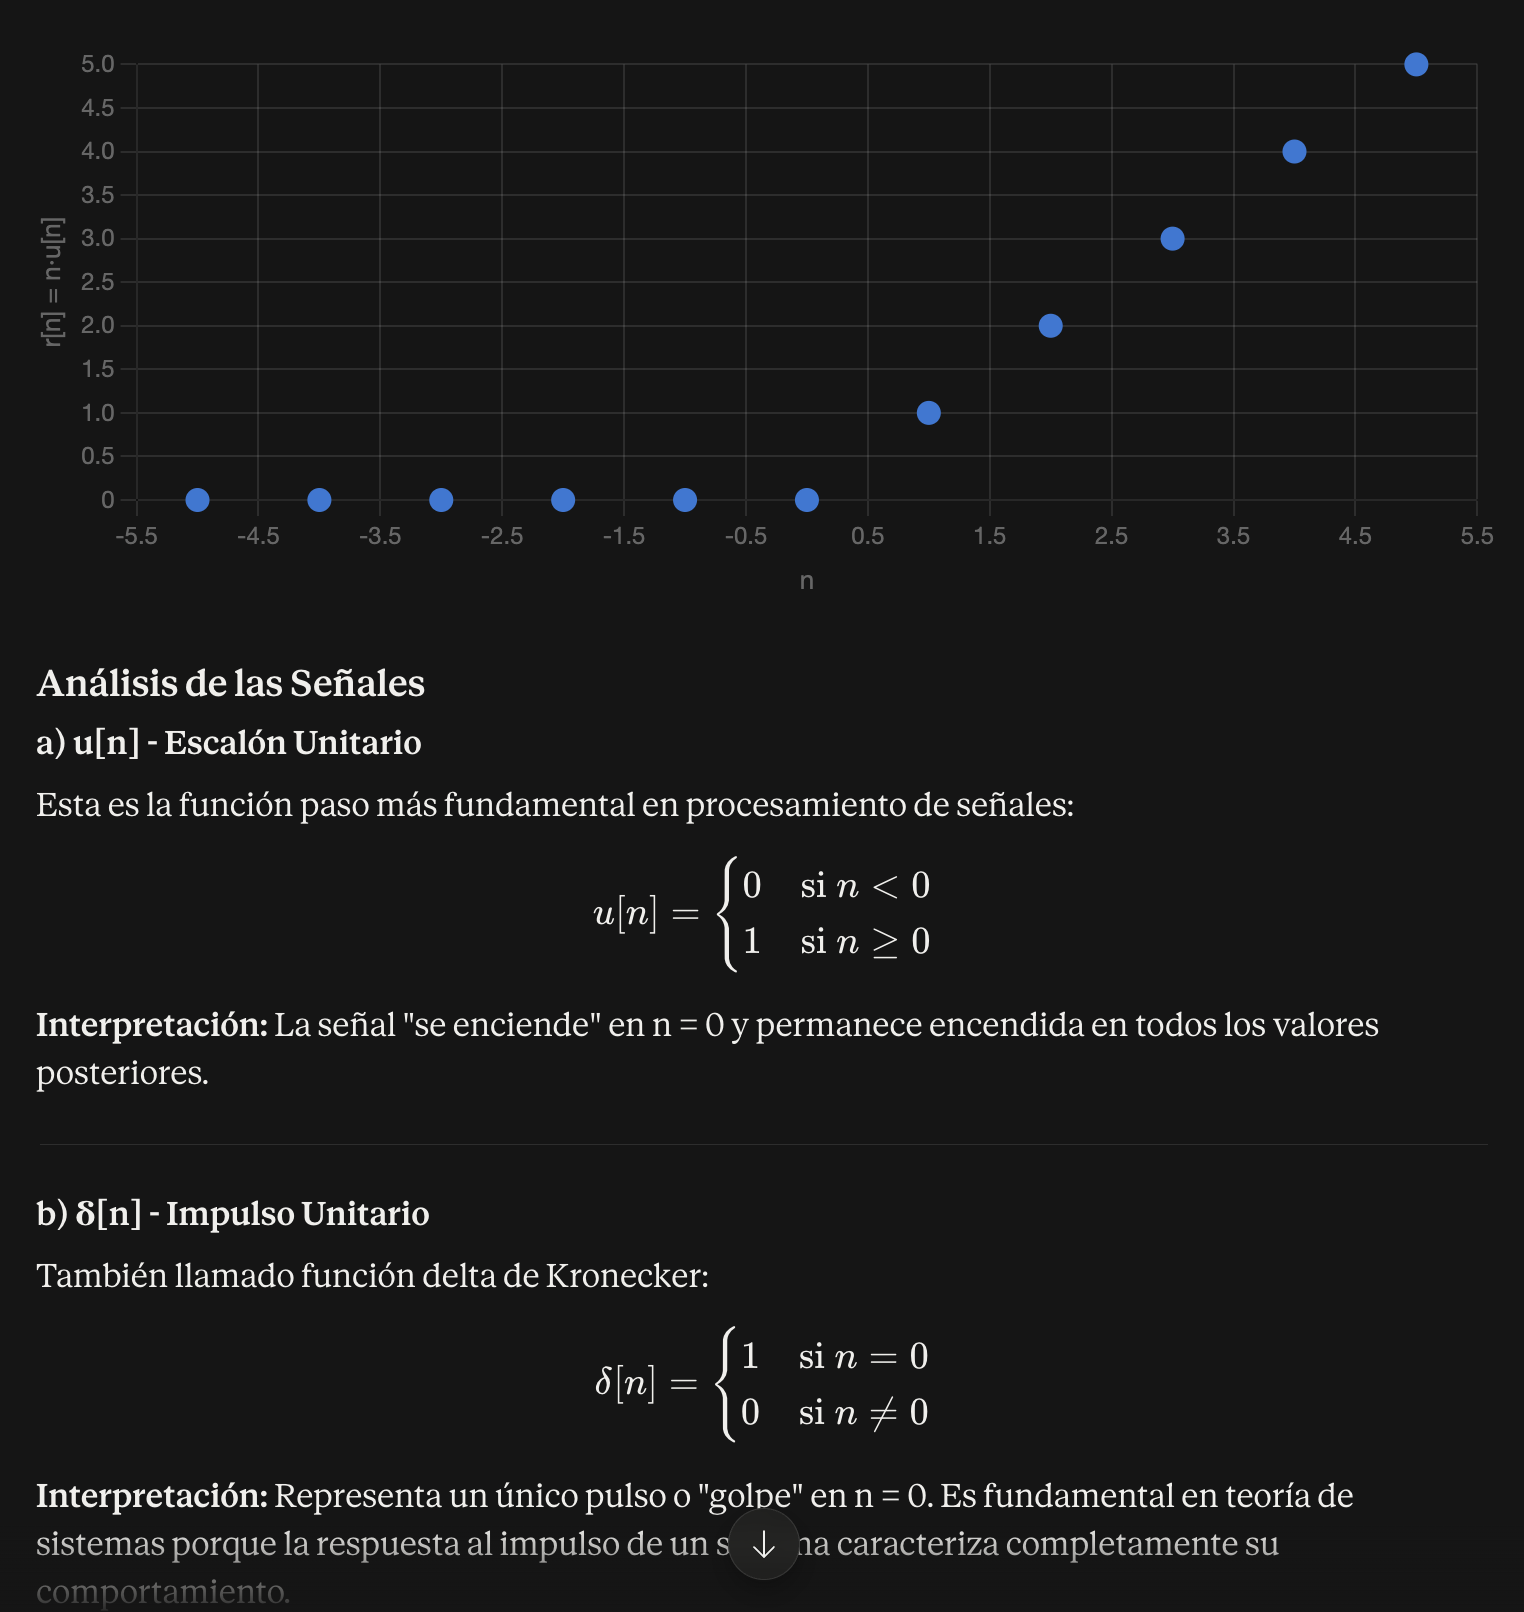

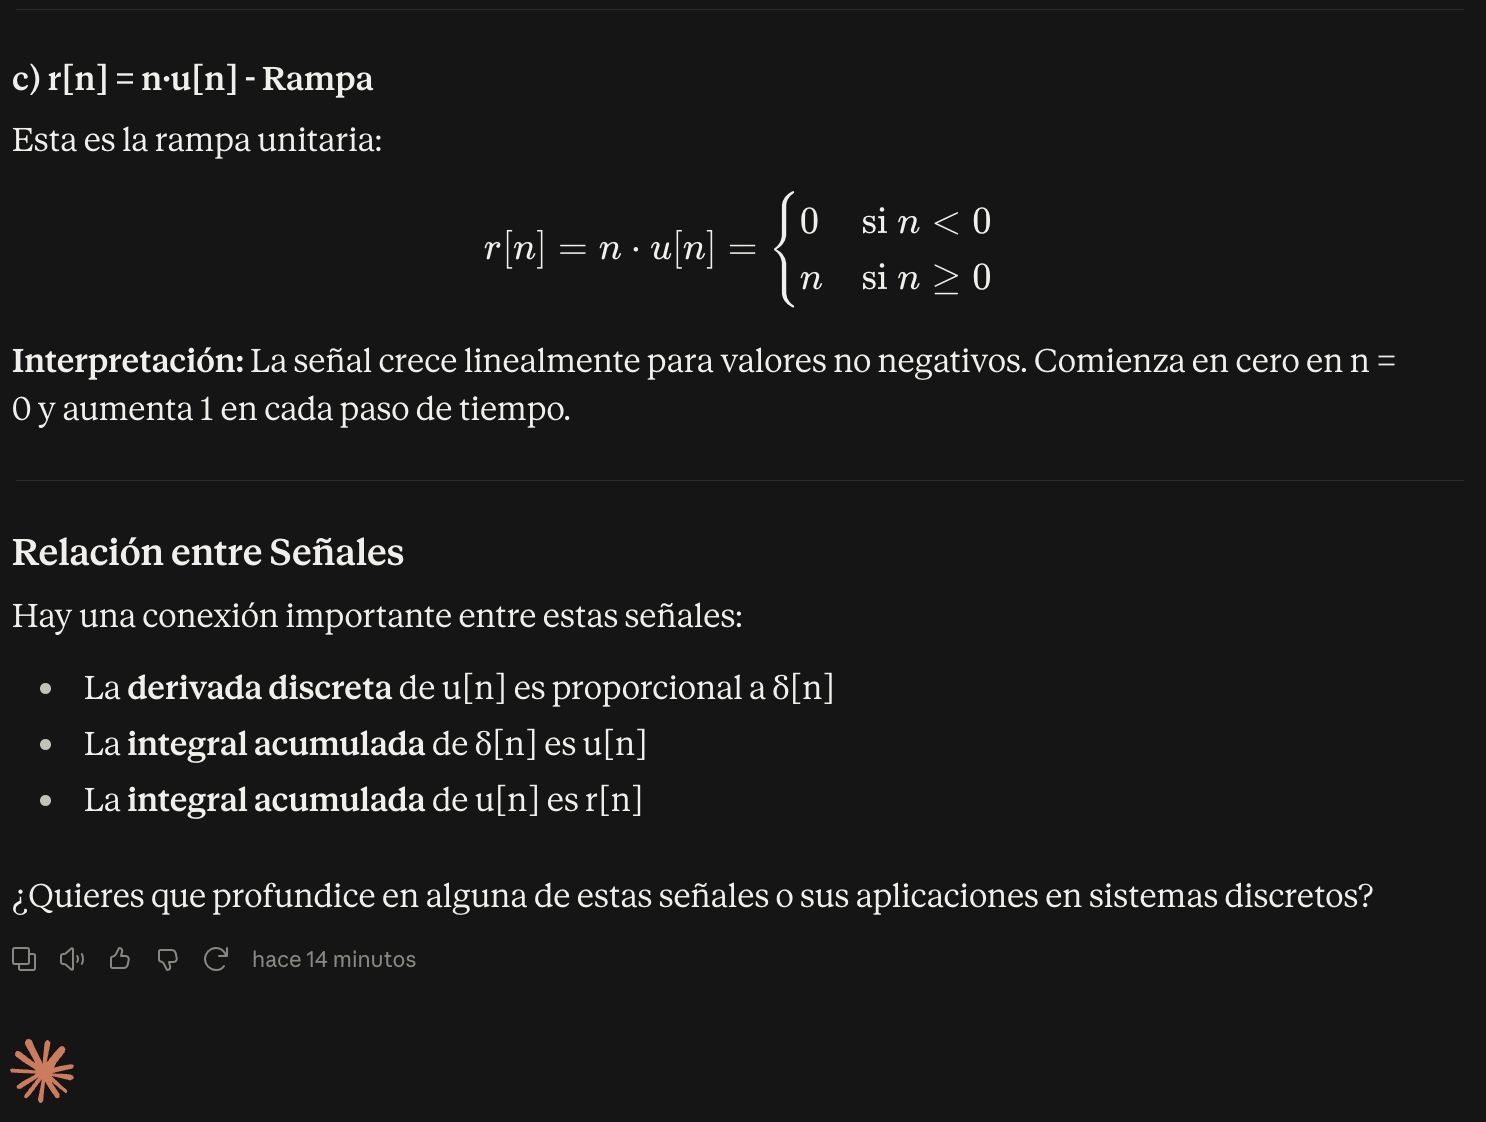

Como se puede ver la respuesta que dio la IA, de igual manera los resultados obtenidos en ambos casos fue correcto, sin embargo la IA profundiza más en la teoria y da la explicación acerca del porque y como estas se relacionan, esta información es correcta y es la que hemos visto en clase y en las otras materias que hemos llevado creemos que es muy comleta y te puede ayudar bastante a repasar estos temas si no recuerdas muy bien este.

Para la pregunta 5 se solicita que:

Given x[n] = {1,2,3,4} for n=0,1,2,3, compute and sketch x[-n].

Para ello lo nostros realizamos a mano fue:

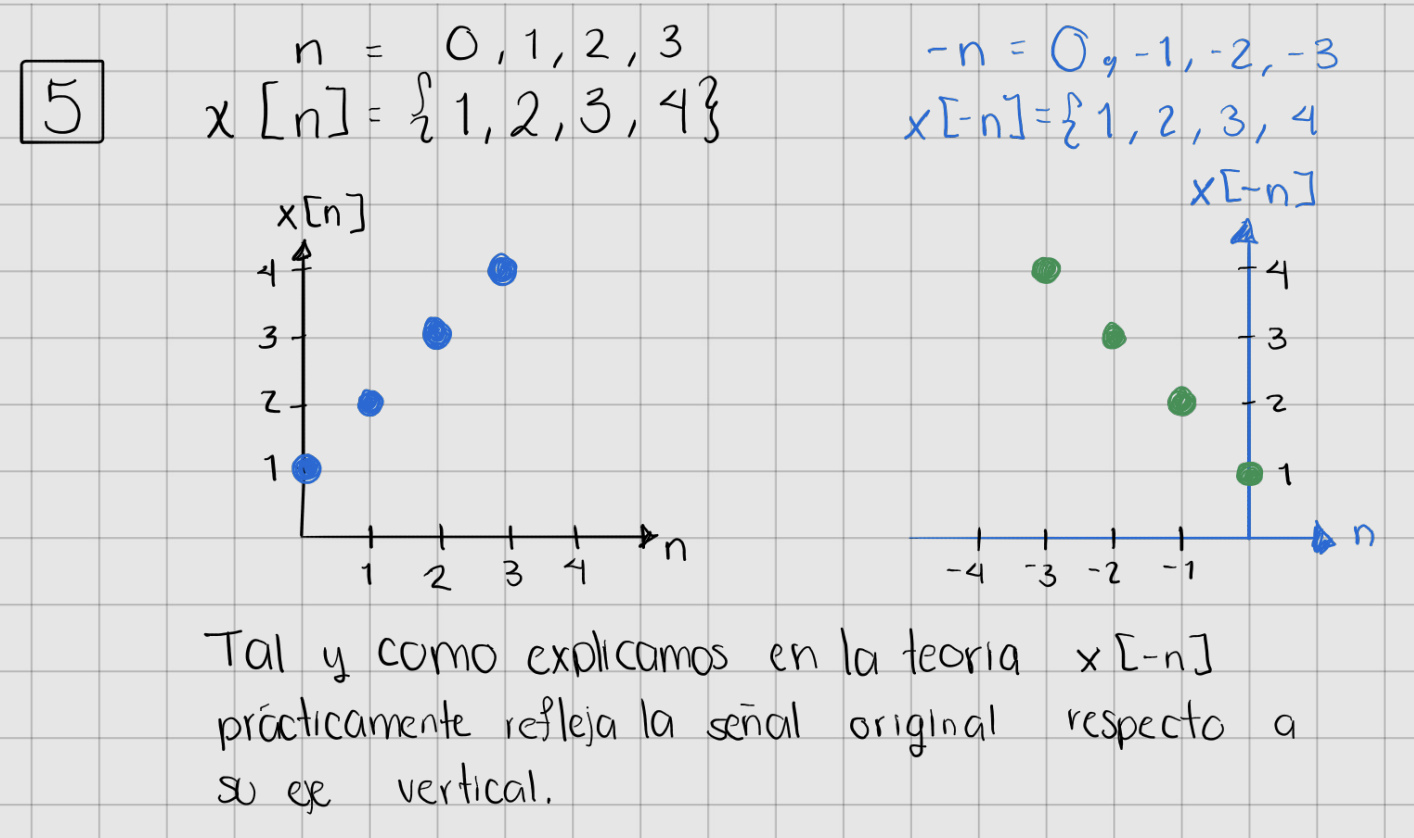

Para esta comparativa usamos la IA de Claude el modelo de Haiku 4.5, el promt usado fue:

'Ahora ayudame a graficar esta señal donde x[n] = {1,2,3,4} para n=0,1,2,3, además también grafica cuando x[-n].'

La respuesta que nos dio fue el mismo resultado que obtuvimos a mano:

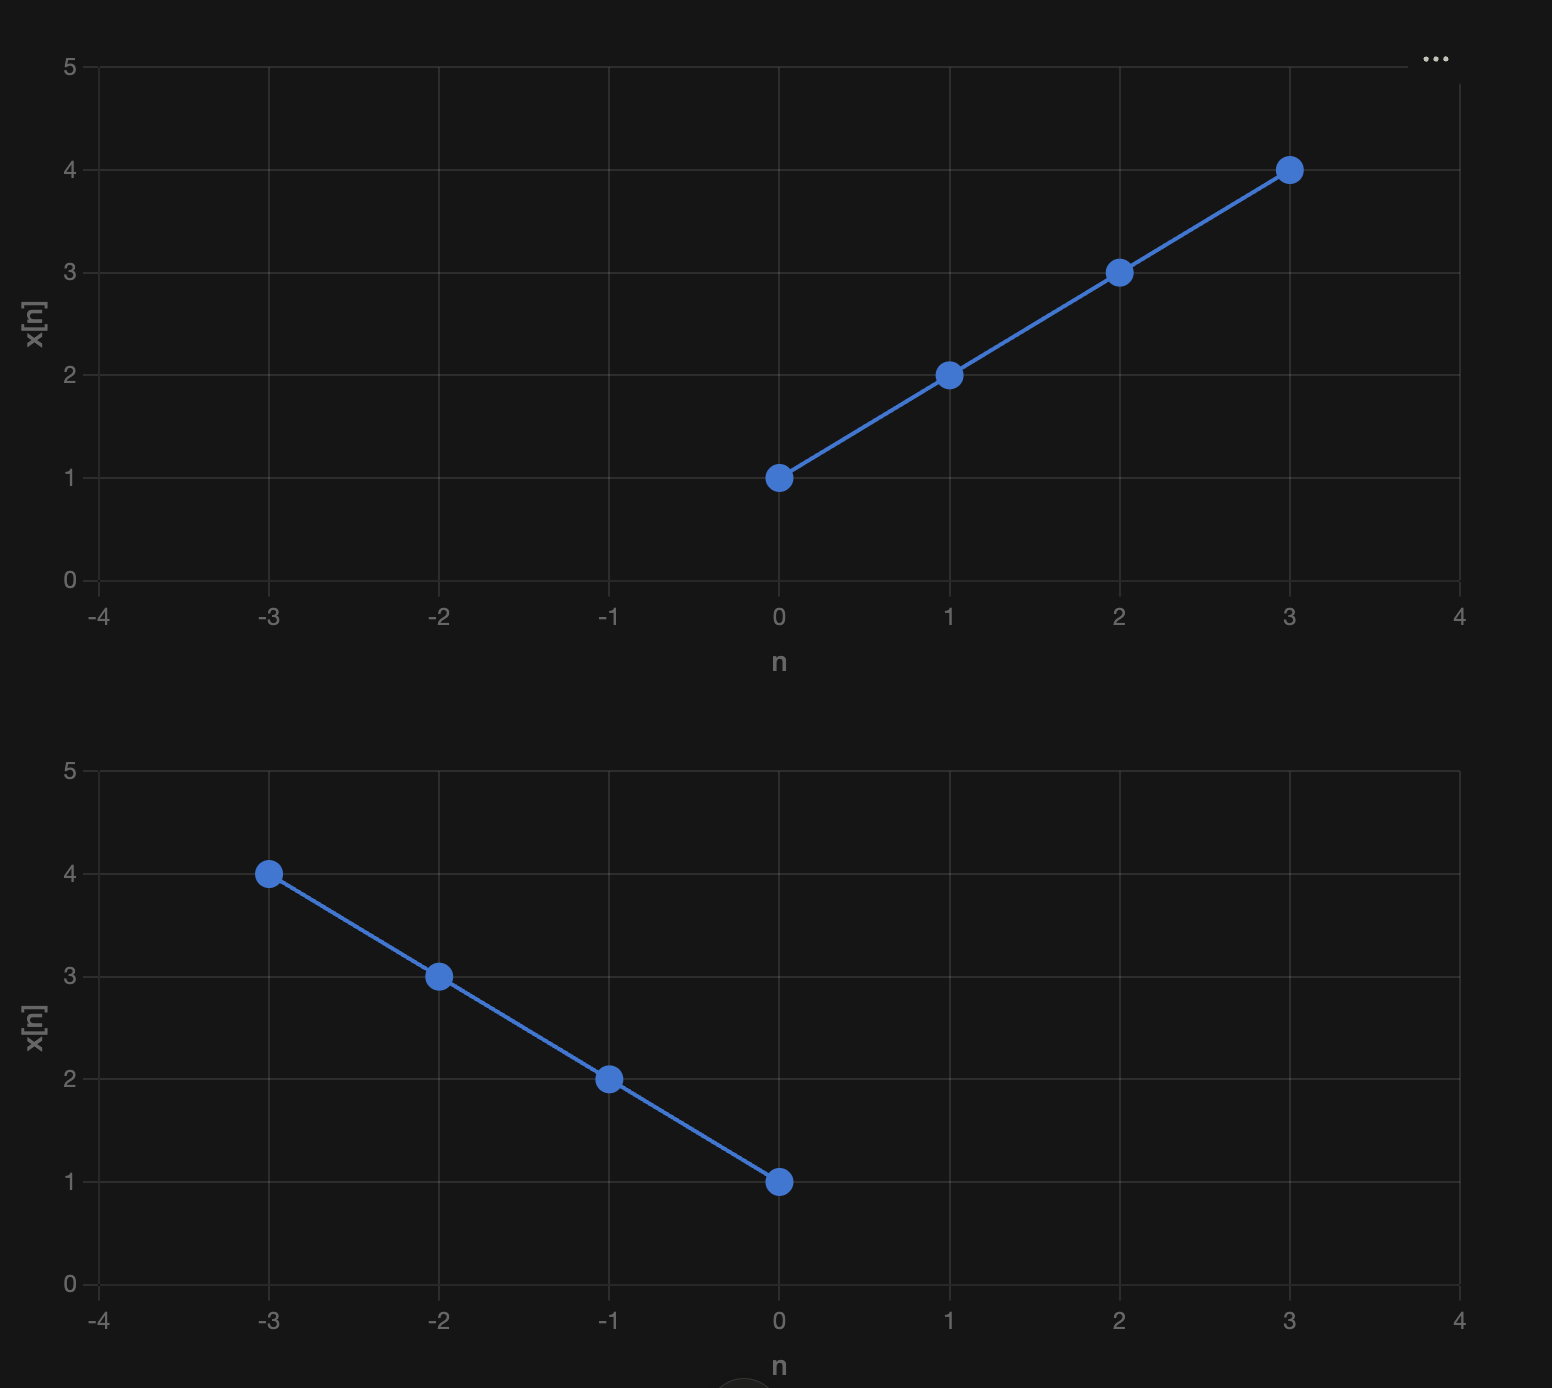

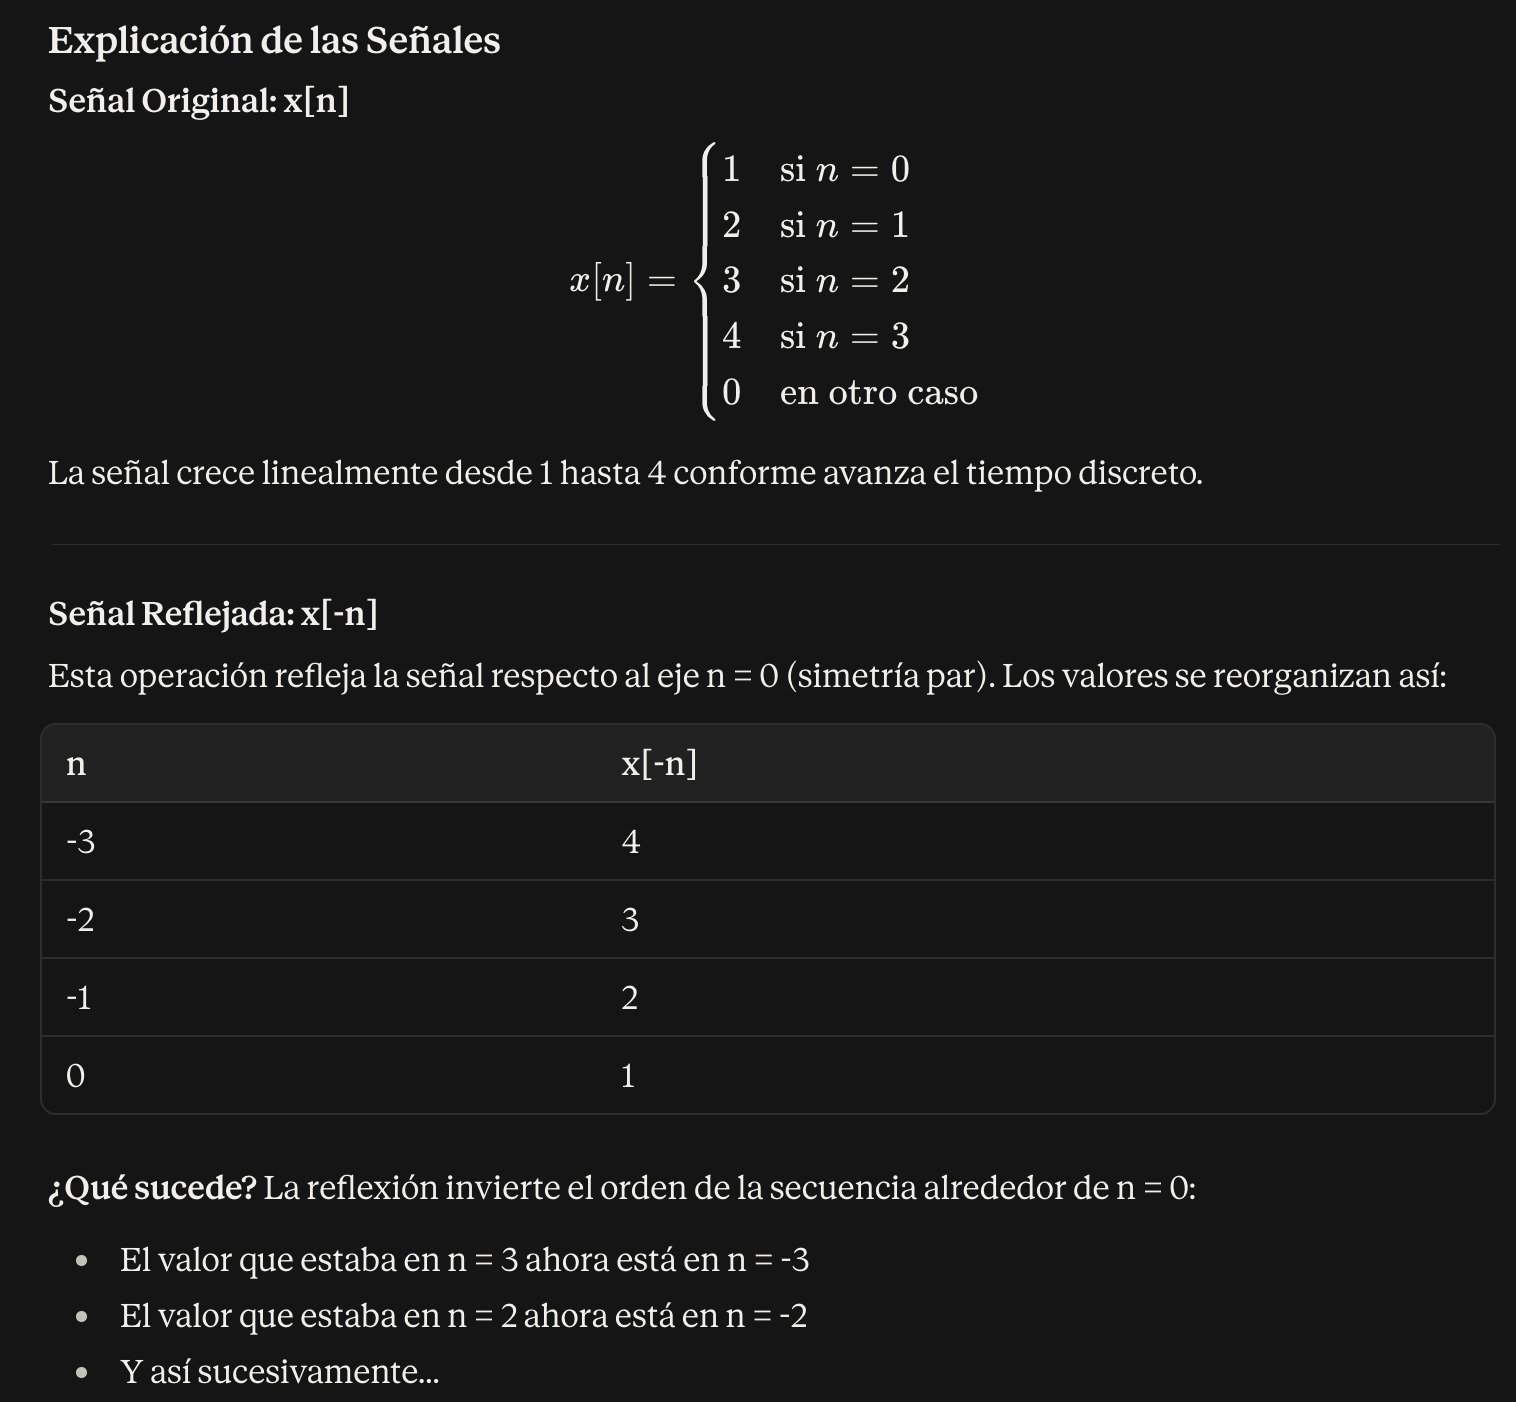

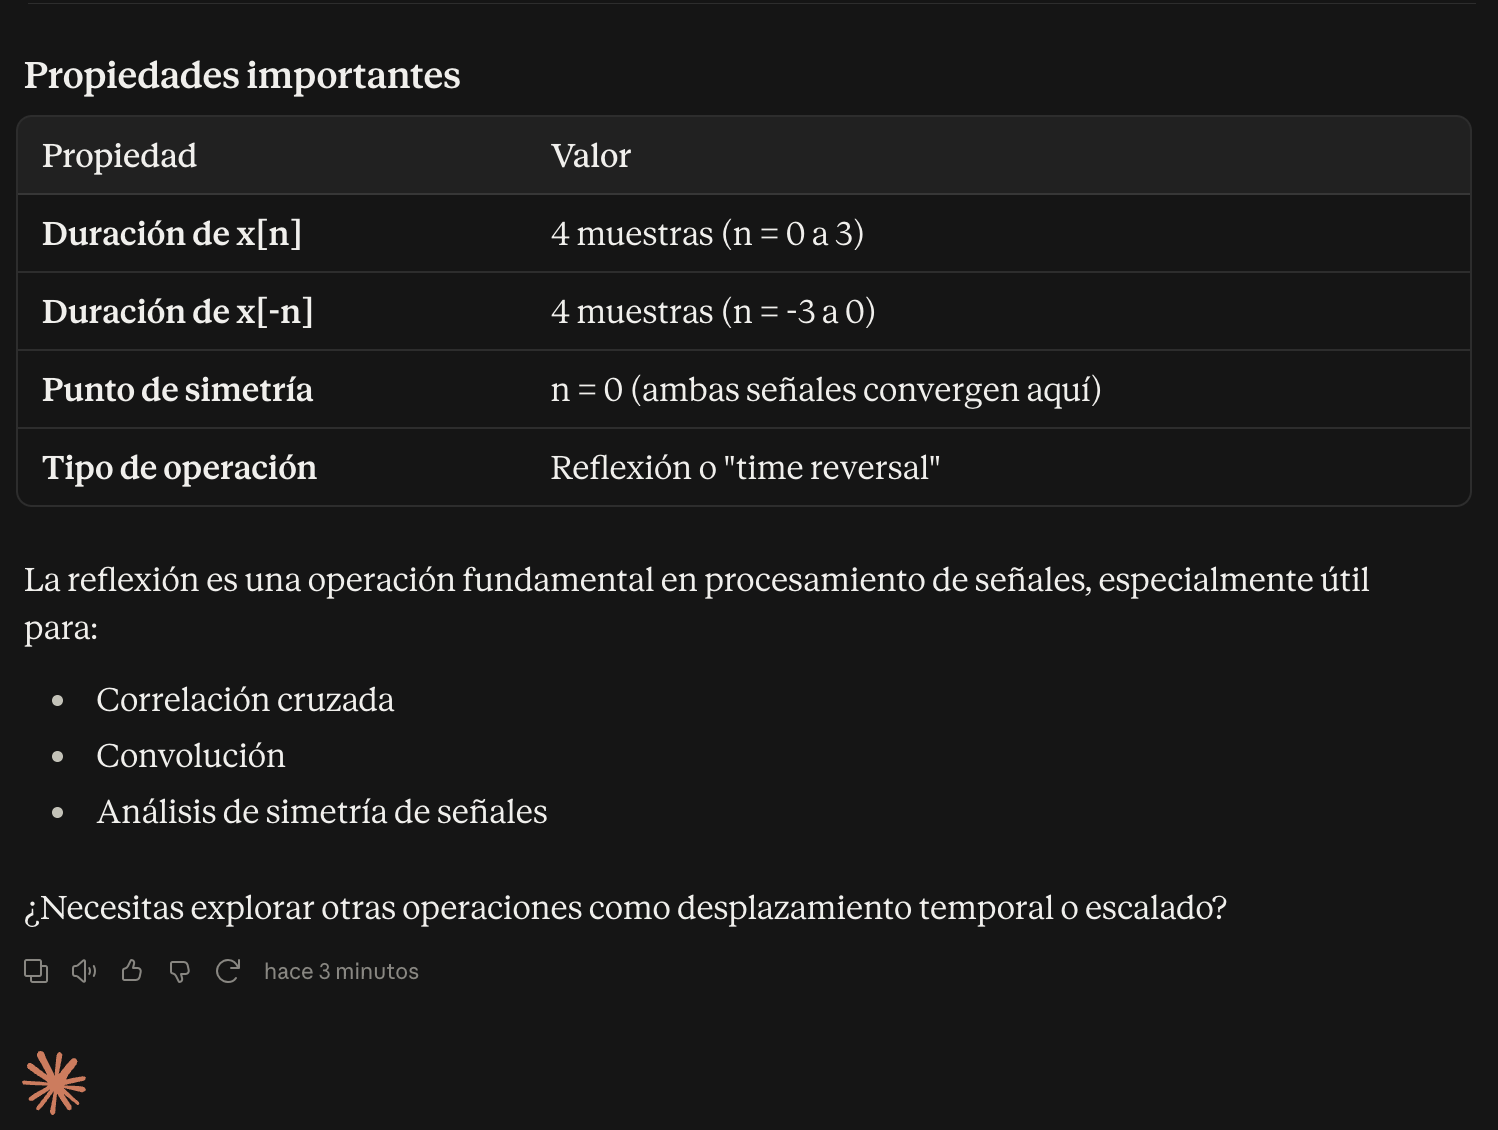

Aqui de igual manera podemos ver como es que ahora con esta pregunta la IA genera las dos graficas identicas a las que tenemos hechas a mano, además de corroborarlo mediante la teoria que explica más abajo, creo igual explica de manera muy simple como es que funciona -n, dejando claro el porque ahora se ve invertida la señal.


## Checklist antes de entregar

- [ ] Tu nombre/matrícula/grupo están completos  
- [ ] Todas las celdas corren sin error  
- [ ] Hay gráficas claras para cada ejercicio  
- [ ] No usaste funciones prohibidas  
- [ ] Incluiste la sección de IA (3 ejercicios mínimo)
